# Blood Cell Image Classification — Data Science Upgrade

**Goal:** classify blood cell images into 4 categories using deep learning, with a more complete data science workflow:
- exploratory data analysis (EDA)
- reproducible train/validation/test setup
- transfer learning with MobileNetV2
- callbacks and fine-tuning
- evaluation with confusion matrix, classification report, ROC curves, precision-recall curves
- error analysis with misclassified examples

Dataset used: `paultimothymooney/blood-cells` from Kaggle.

## 1. Setup & Reproducibility

This section imports all required libraries and fixes random seeds so that results are more reproducible.

In [1]:
# Core
import os
import random
from pathlib import Path
from collections import Counter

# Data
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt

# ML / DL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.10.0


## 2. Download / Locate Dataset

Run this cell if you are using KaggleHub locally.  
If you are already in Kaggle, you can set `DATA_ROOT` manually to the dataset path.

In [2]:
# Install only if needed:
# !pip install kagglehub

try:
    import kagglehub
    dataset_path = kagglehub.dataset_download("paultimothymooney/blood-cells")
    print("Dataset downloaded to:", dataset_path)
except Exception as e:
    print("KaggleHub not available or dataset already exists.")
    print("Error:", e)
    dataset_path = None

c:\Users\User\miniconda3\envs\tf_directml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\User\.cache\kagglehub\datasets\paultimothymooney\blood-cells\versions\6


In [3]:
# Set dataset folders
# Expected structure:
# dataset2-master/dataset2-master/images/TRAIN
# dataset2-master/dataset2-master/images/TEST

if dataset_path is not None:
    DATA_ROOT = Path(dataset_path) / "dataset2-master" / "dataset2-master" / "images"
else:
    # Change this path if you run inside Kaggle or locally
    DATA_ROOT = Path("/kaggle/input/blood-cells/dataset2-master/dataset2-master/images")

TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR = DATA_ROOT / "TEST"

print("Train exists:", TRAIN_DIR.exists(), TRAIN_DIR)
print("Test exists:", TEST_DIR.exists(), TEST_DIR)

Train exists: True C:\Users\User\.cache\kagglehub\datasets\paultimothymooney\blood-cells\versions\6\dataset2-master\dataset2-master\images\TRAIN
Test exists: True C:\Users\User\.cache\kagglehub\datasets\paultimothymooney\blood-cells\versions\6\dataset2-master\dataset2-master\images\TEST


## 3. Exploratory Data Analysis (EDA)

Before training, check:
- number of images per class
- class imbalance
- sample images
- image sizes

In [4]:
def count_images_by_class(directory):
    rows = []
    for class_dir in sorted([p for p in Path(directory).iterdir() if p.is_dir()]):
        image_files = list(class_dir.glob("*"))
        rows.append({"class": class_dir.name, "count": len(image_files)})
    return pd.DataFrame(rows)

train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

display(train_counts)
display(test_counts)

,class,count
0,EOSINOPHIL,2497
1,LYMPHOCYTE,2483
2,MONOCYTE,2478
3,NEUTROPHIL,2499


,class,count
0,EOSINOPHIL,623
1,LYMPHOCYTE,620
2,MONOCYTE,620
3,NEUTROPHIL,624


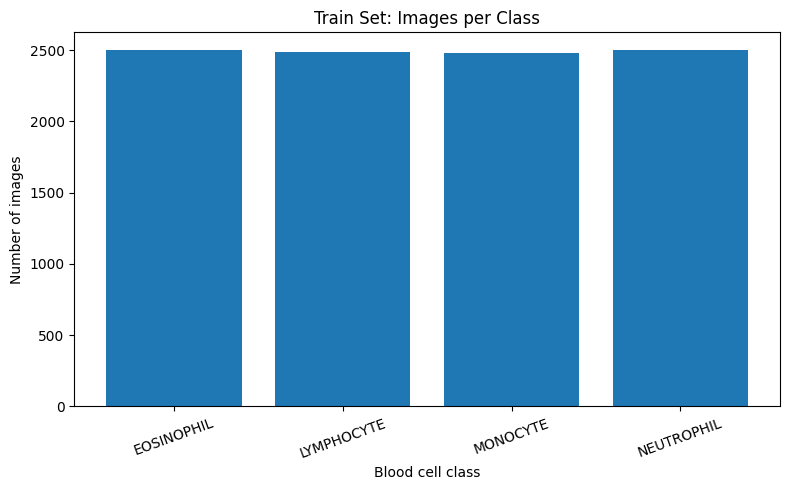

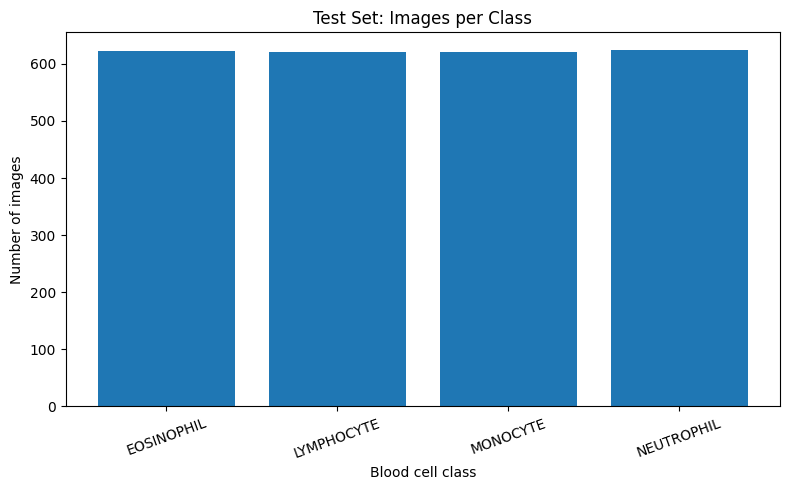

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(train_counts["class"], train_counts["count"])
plt.title("Train Set: Images per Class")
plt.xlabel("Blood cell class")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(test_counts["class"], test_counts["count"])
plt.title("Test Set: Images per Class")
plt.xlabel("Blood cell class")
plt.ylabel("Number of images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

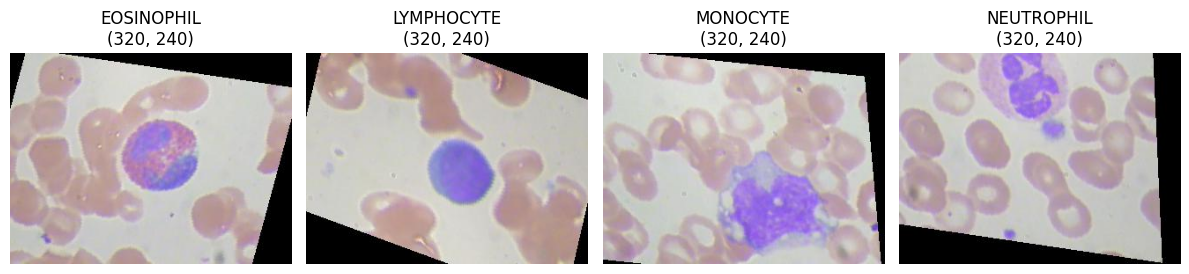

In [6]:
from PIL import Image

def show_sample_images(directory, max_classes=4):
    class_dirs = sorted([p for p in Path(directory).iterdir() if p.is_dir()])[:max_classes]
    plt.figure(figsize=(12, 4))
    for i, class_dir in enumerate(class_dirs):
        img_path = next(class_dir.glob("*"))
        img = Image.open(img_path)
        plt.subplot(1, len(class_dirs), i + 1)
        plt.imshow(img)
        plt.title(f"{class_dir.name}\n{img.size}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(TRAIN_DIR)

## 4. Train / Validation / Test Split — Diagnosis & Fix

**Diagnosis:** train/val reached ~90% accuracy (see training logs below) but the original `TEST/` folder only scored ~56%. Since validation is genuinely held-out data and still scored high, the model is not the problem. The conclusion: Kaggle's pre-made `TRAIN/` and `TEST/` folders are not from the same distribution (different cropping/augmentation when the dataset was built), so evaluating against `TEST/` as-is is misleading.

**Fix:** pool `TRAIN/` + `TEST/` together, drop any unreadable image files, then create our own stratified 70/15/15 split. This gives a validation/test set that is actually representative of the training data.

In [7]:
from sklearn.model_selection import train_test_split
from PIL import Image

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
NUM_CLASSES = len(class_names)

# Pool TRAIN + TEST together instead of trusting the predefined split (see diagnosis above)
all_paths, all_labels = [], []
for idx, cls in enumerate(class_names):
    files = list((TRAIN_DIR / cls).glob("*")) + list((TEST_DIR / cls).glob("*"))
    all_paths.extend(str(f) for f in files)
    all_labels.extend([idx] * len(files))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

# Quick corrupt / unreadable file check
is_valid = []
for p in all_paths:
    try:
        Image.open(p).verify()
        is_valid.append(True)
    except Exception:
        is_valid.append(False)
is_valid = np.array(is_valid)
print("Unreadable files removed:", (~is_valid).sum())
all_paths, all_labels = all_paths[is_valid], all_labels[is_valid]

# Stratified 70 / 15 / 15 split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, tf.one_hot(label, NUM_CLASSES)

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds = make_dataset(val_paths, val_labels)
test_ds = make_dataset(test_paths, test_labels)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

Unreadable files removed: 0
Train: 8710  Val: 1867  Test: 1867
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Number of classes: 4


## 5. Handle Class Imbalance

If classes are imbalanced, class weights help the model avoid focusing too much on the largest class.

In [8]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)

class_weights = {i: w for i, w in enumerate(class_weights_array)}
class_weights

{0: 0.9970238095238095,
 1: 1.0025322283609577,
 2: 1.0043819188191883,
 3: 0.9961116193961573}

## 6. Model 1 — Transfer Learning with MobileNetV2

This is usually stronger and more portfolio-friendly than a simple custom CNN because it uses ImageNet features.

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.20)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="MobileNetV2_BloodCell_Classifier")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "MobileNetV2_BloodCell_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 160, 160, 3)      0         
 al)                                                             
                                                                 
 tf.math.truediv (TFOpLambda  (None, 160, 160, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 160, 160, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                           

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        "best_blood_cell_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [11]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/20
273/273 [==============================] - 129s 452ms/step - loss: 1.2028 - accuracy: 0.4701 - val_loss: 1.0209 - val_accuracy: 0.5544 - lr: 0.0010
Epoch 2/20
273/273 [==============================] - 122s 445ms/step - loss: 0.9854 - accuracy: 0.5823 - val_loss: 0.8492 - val_accuracy: 0.6529 - lr: 0.0010
Epoch 3/20
273/273 [==============================] - 126s 461ms/step - loss: 0.9008 - accuracy: 0.6224 - val_loss: 0.7945 - val_accuracy: 0.6749 - lr: 0.0010
Epoch 4/20
273/273 [==============================] - 121s 445ms/step - loss: 0.8591 - accuracy: 0.6425 - val_loss: 0.8276 - val_accuracy: 0.6674 - lr: 0.0010
Epoch 5/20
273/273 [==============================] - 131s 481ms/step - loss: 0.8257 - accuracy: 0.6580 - val_loss: 0.6997 - val_accuracy: 0.7349 - lr: 0.0010
Epoch 6/20
273/273 [==============================] - 132s 482ms/step - loss: 0.7952 - accuracy: 0.6651 - val_loss: 0.7466 - val_accuracy: 0.6936 - lr: 0.0010
Epoch 7/20
273/273 [==========================

## 7. Training Curves

These plots show whether the model is learning or overfitting.

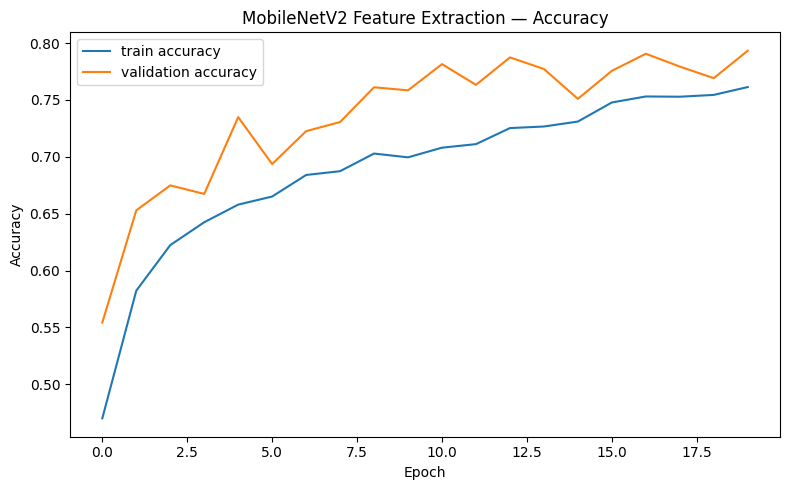

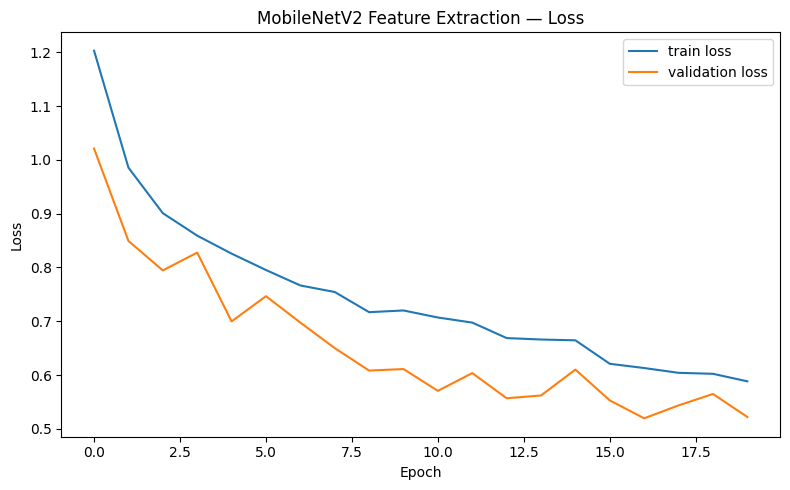

In [12]:
def plot_training_history(history, title="Training History"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="train accuracy")
    plt.plot(hist["val_accuracy"], label="validation accuracy")
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="validation loss")
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_training_history(history, "MobileNetV2 Feature Extraction")

## 8. Fine-Tuning

After the classifier head learns, unfreeze the last layers of MobileNetV2 and train with a very small learning rate.

In [13]:
base_model.trainable = True

# Freeze most layers, train only the last part
fine_tune_at = int(len(base_model.layers) * 0.75)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10
273/273 [==============================] - 135s 469ms/step - loss: 0.5598 - accuracy: 0.7784 - val_loss: 0.5084 - val_accuracy: 0.7890 - lr: 1.0000e-05
Epoch 2/10
273/273 [==============================] - 126s 461ms/step - loss: 0.4592 - accuracy: 0.8156 - val_loss: 0.3671 - val_accuracy: 0.8565 - lr: 1.0000e-05
Epoch 3/10
273/273 [==============================] - 125s 458ms/step - loss: 0.3988 - accuracy: 0.8392 - val_loss: 0.4214 - val_accuracy: 0.8286 - lr: 1.0000e-05
Epoch 4/10
273/273 [==============================] - 125s 459ms/step - loss: 0.3498 - accuracy: 0.8575 - val_loss: 0.2703 - val_accuracy: 0.8923 - lr: 1.0000e-05
Epoch 5/10
273/273 [==============================] - 125s 456ms/step - loss: 0.3249 - accuracy: 0.8738 - val_loss: 0.3227 - val_accuracy: 0.8634 - lr: 1.0000e-05
Epoch 6/10
273/273 [==============================] - 125s 458ms/step - loss: 0.2901 - accuracy: 0.8860 - val_loss: 0.2442 - val_accuracy: 0.8982 - lr: 1.0000e-05
Epoch 7/10
273/273 [==

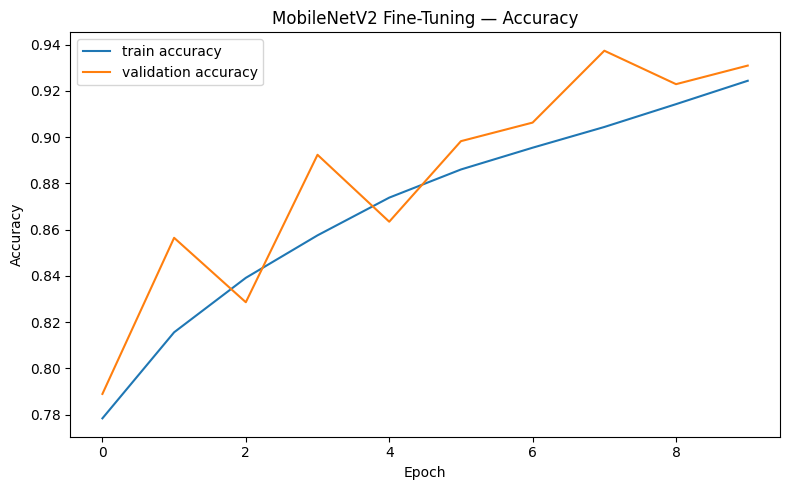

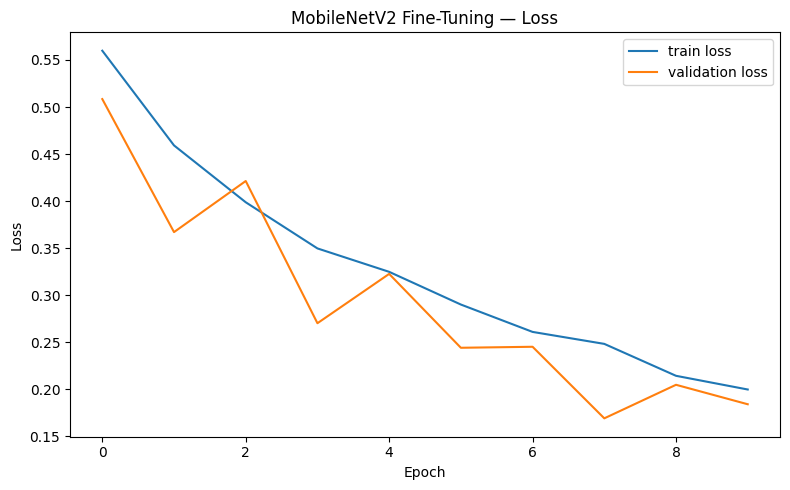

In [14]:
plot_training_history(fine_tune_history, "MobileNetV2 Fine-Tuning")

## 9. Final Test Evaluation

The test set is used only at the end.  
This gives a more honest estimate of model performance.

In [15]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

59/59 [==============================] - 2s 27ms/step - loss: 0.2180 - accuracy: 0.9159
Test Loss: 0.2180
Test Accuracy: 0.9159


In [16]:
# Get true labels and predicted probabilities
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob.append(probs)
    y_true.append(labels.numpy())

y_prob = np.vstack(y_prob)
y_true_onehot = np.vstack(y_true)

y_true_labels = np.argmax(y_true_onehot, axis=1)
y_pred_labels = np.argmax(y_prob, axis=1)

print("Predictions shape:", y_prob.shape)

Predictions shape: (1867, 4)


## 10. Confusion Matrix

This shows which classes the model confuses with each other.

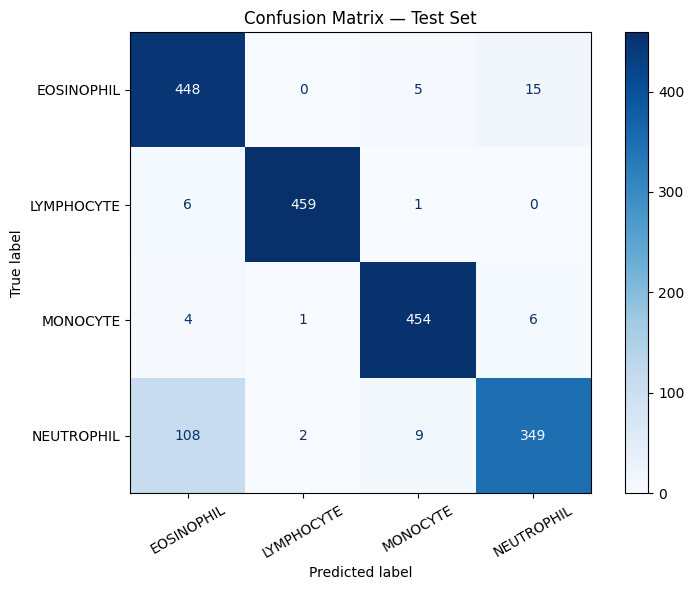

In [17]:
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Confusion Matrix — Test Set")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

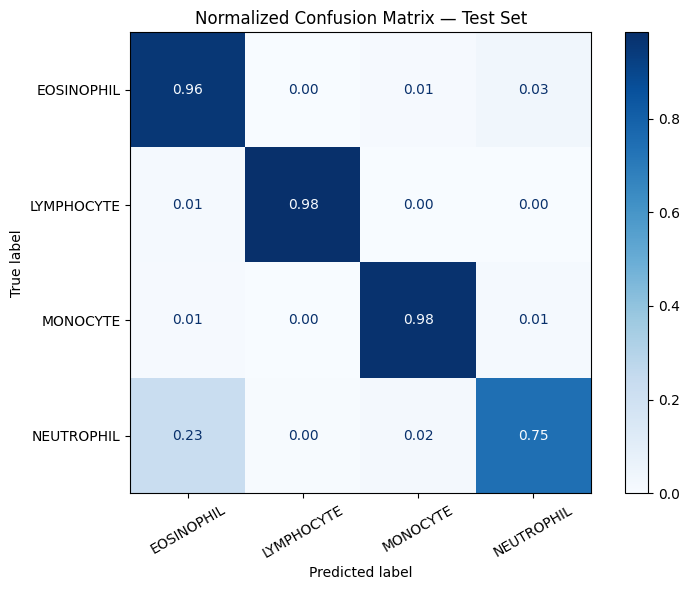

In [18]:
cm_norm = confusion_matrix(y_true_labels, y_pred_labels, normalize="true")

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(cmap="Blues", values_format=".2f", ax=plt.gca())
plt.title("Normalized Confusion Matrix — Test Set")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 11. Classification Report

For a data science portfolio, do not show only accuracy.  
Also show:
- precision
- recall
- F1-score
- macro average
- weighted average

In [19]:
report_dict = classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

report_df.to_csv("classification_report.csv", index=True)

,precision,recall,f1-score,support
EOSINOPHIL,0.791519,0.957265,0.866538,468.000000
LYMPHOCYTE,0.993506,0.984979,0.989224,466.000000
MONOCYTE,0.968017,0.976344,0.972163,465.000000
NEUTROPHIL,0.943243,0.745726,0.832936,468.000000
accuracy,0.915908,0.915908,0.915908,0.915908
macro avg,0.924072,0.916079,0.915215,1867.000000
weighted avg,0.923927,0.915908,0.915044,1867.000000


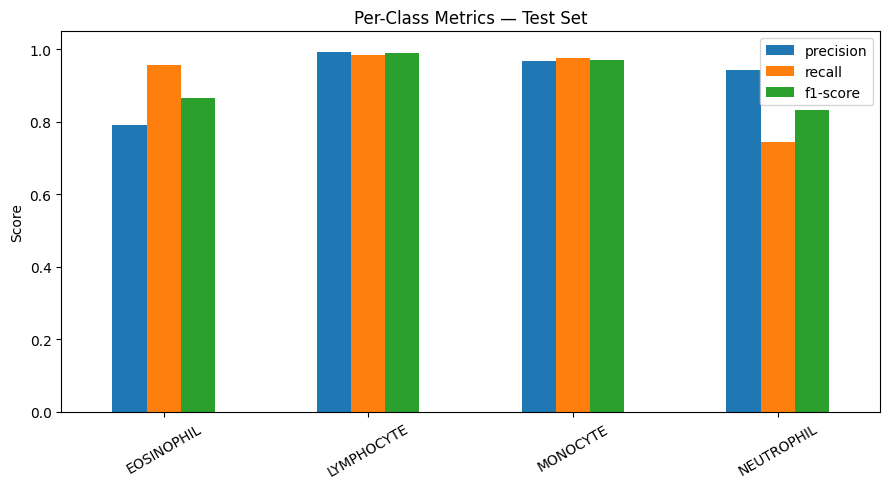

In [20]:
# Visualize per-class precision, recall, F1
per_class_report = report_df.loc[class_names, ["precision", "recall", "f1-score"]]

per_class_report.plot(kind="bar", figsize=(9, 5))
plt.title("Per-Class Metrics — Test Set")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 12. ROC Curves — One-vs-Rest

ROC curves help show how well the model separates each class from the others.

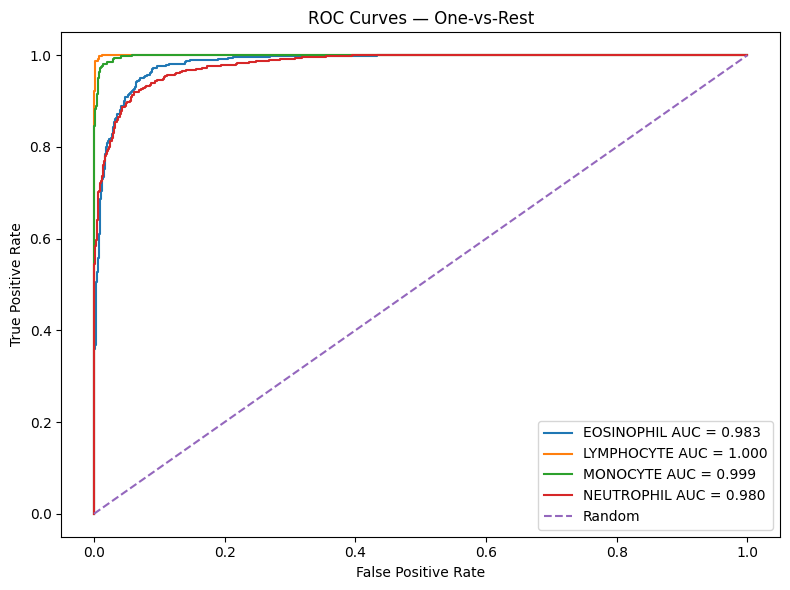

In [21]:
y_true_bin = label_binarize(y_true_labels, classes=np.arange(NUM_CLASSES))

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curves — One-vs-Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Error Analysis — Misclassified Images

This is one of the most important portfolio additions.  
It shows that you do not only train a model, you also analyze its mistakes.

Misclassified images: 157


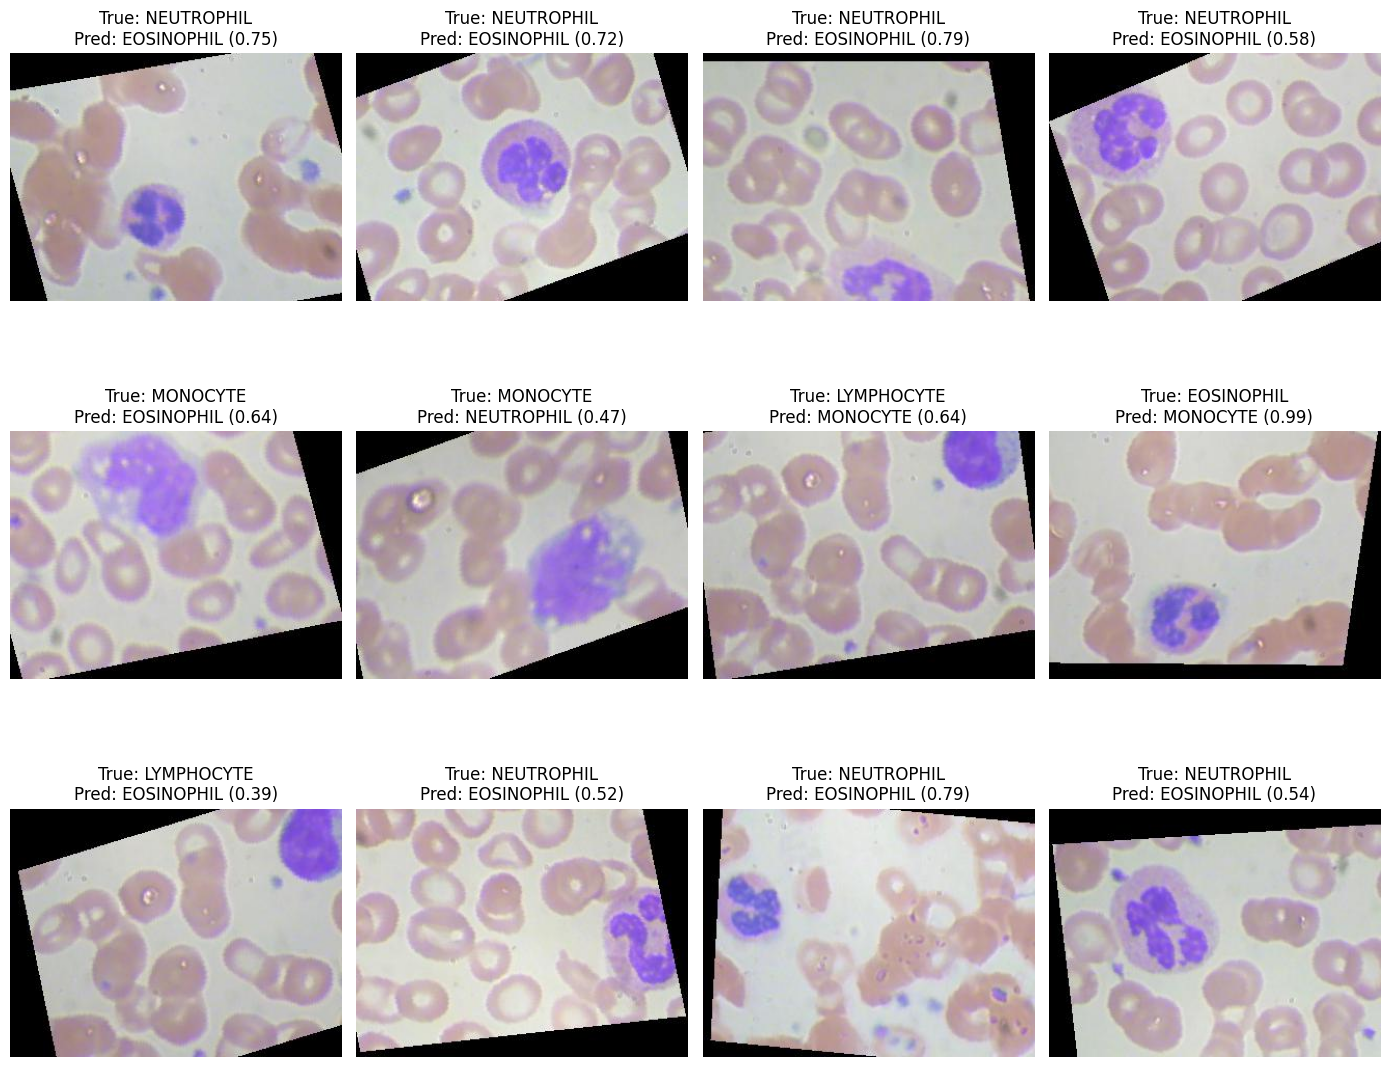

In [22]:
# Collect test file paths in same order as image_dataset_from_directory with shuffle=False
test_file_paths = test_paths  # from the stratified split (test_ds is not shuffled)

wrong_idx = np.where(y_true_labels != y_pred_labels)[0]
print("Misclassified images:", len(wrong_idx))

def show_misclassified_examples(max_images=12):
    if len(wrong_idx) == 0:
        print("No misclassified examples found.")
        return

    sample_idx = wrong_idx[:max_images]
    cols = 4
    rows = int(np.ceil(len(sample_idx) / cols))

    plt.figure(figsize=(14, 4 * rows))
    for plot_i, idx in enumerate(sample_idx):
        img = Image.open(test_file_paths[idx])
        true_name = class_names[y_true_labels[idx]]
        pred_name = class_names[y_pred_labels[idx]]
        confidence = y_prob[idx, y_pred_labels[idx]]

        plt.subplot(rows, cols, plot_i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_name}\nPred: {pred_name} ({confidence:.2f})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified_examples()

## 14. Prediction Confidence Analysis

A reliable model should not only be accurate; it should also show reasonable confidence.

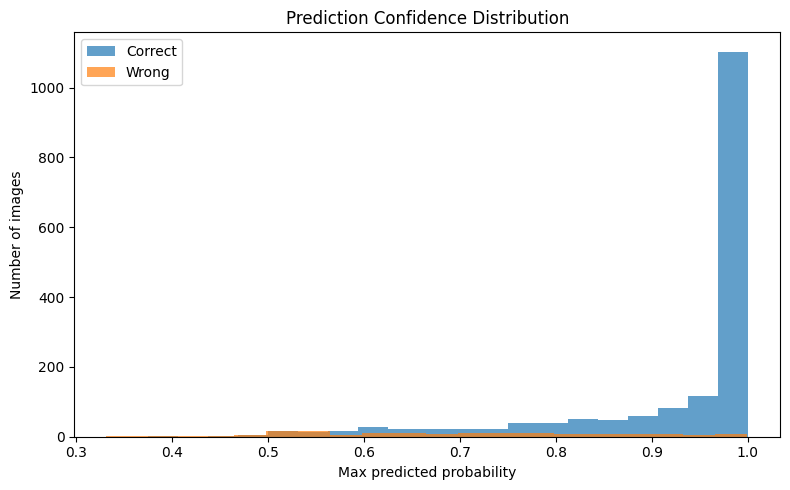

Average confidence — correct: 0.93011594
Average confidence — wrong: 0.694903


In [23]:
max_confidence = np.max(y_prob, axis=1)
correct = y_true_labels == y_pred_labels

plt.figure(figsize=(8, 5))
plt.hist(max_confidence[correct], bins=20, alpha=0.7, label="Correct")
plt.hist(max_confidence[~correct], bins=20, alpha=0.7, label="Wrong")
plt.title("Prediction Confidence Distribution")
plt.xlabel("Max predicted probability")
plt.ylabel("Number of images")
plt.legend()
plt.tight_layout()
plt.show()

print("Average confidence — correct:", max_confidence[correct].mean() if correct.any() else None)
print("Average confidence — wrong:", max_confidence[~correct].mean() if (~correct).any() else None)

## 15. Save Final Model

Save the trained model so it can be reused later in an app/API/demo.

In [24]:
model.save("blood_cell_mobilenetv2_final.keras")
print("Model saved as blood_cell_mobilenetv2_final.keras")

Model saved as blood_cell_mobilenetv2_final.keras


## 16. Portfolio Summary

Use this paragraph in GitHub/LinkedIn:

> This project classifies microscopic blood cell images using a transfer learning pipeline based on MobileNetV2. The workflow includes exploratory data analysis, image preprocessing, data augmentation, class imbalance handling, early stopping, learning-rate scheduling, fine-tuning, and complete model evaluation using accuracy, precision, recall, F1-score, confusion matrix, ROC curves, precision-recall curves, and misclassification analysis.

### Why this version is stronger
- Uses a separate test set for honest final evaluation.
- Uses validation correctly without augmentation leakage.
- Adds callbacks to reduce overfitting.
- Adds class weights for imbalance.
- Uses transfer learning and fine-tuning.
- Includes explainable evaluation charts instead of only accuracy.
- Includes error analysis, which makes the project look more mature.